https://www.arundo.com/articles/adtk-open-source-time-series-anomaly-detection-in-python

In [ ]:
pip install adtk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 841.3 kB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# служебные функции
from adtk.data import validate_series
from adtk.visualization import plot
# Статистические методы детектирования точечных аномалий
from adtk.detector import ThresholdAD
from adtk.detector import QuantileAD
from adtk.detector import InterQuartileRangeAD
from adtk.detector import GeneralizedESDTestAD
# Статистические методы детектирования групповых аномалий
from adtk.detector import PersistAD
from adtk.detector import LevelShiftAD
from adtk.detector import VolatilityShiftAD
# методы на основе декомпозиции временного ряда и авторегрессии
from adtk.detector import SeasonalAD
from adtk.detector import AutoregressionAD
# Методы на основе кластеризации - неконтролируемое обучение
from adtk.detector import MinClusterDetector
from sklearn.cluster import KMeans
# Методы на основе плотности
from adtk.detector import OutlierDetector
from sklearn.neighbors import LocalOutlierFactor
# Методы на основе регрессии - контролируемое обучение
from adtk.detector import RegressionAD
from sklearn.linear_model import LinearRegression
# Методы на основе понижения размерности
from adtk.detector import PcaAD
# кастомизация
from adtk.detector import CustomizedDetectorHD

1. Просто по пороговому значению: что может быть проще?

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/temperature.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

In [ ]:
s

,Temperature (C)
Time,
2017-05-02 00:00:00,18.91
2017-05-02 01:00:00,19.91
2017-05-02 02:00:00,20.19
2017-05-02 03:00:00,18.69
2017-05-02 04:00:00,18.11
...,...
2017-05-10 03:00:00,21.70
2017-05-10 04:00:00,21.43
2017-05-10 05:00:00,21.32


In [ ]:
threshold_ad = ThresholdAD(high=30, low=15) # модель определения аномалий по пороговому значению
anomalies = threshold_ad.detect(s)

In [ ]:
anomalies.value_counts()

,count
Temperature (C),
False,184
True,16


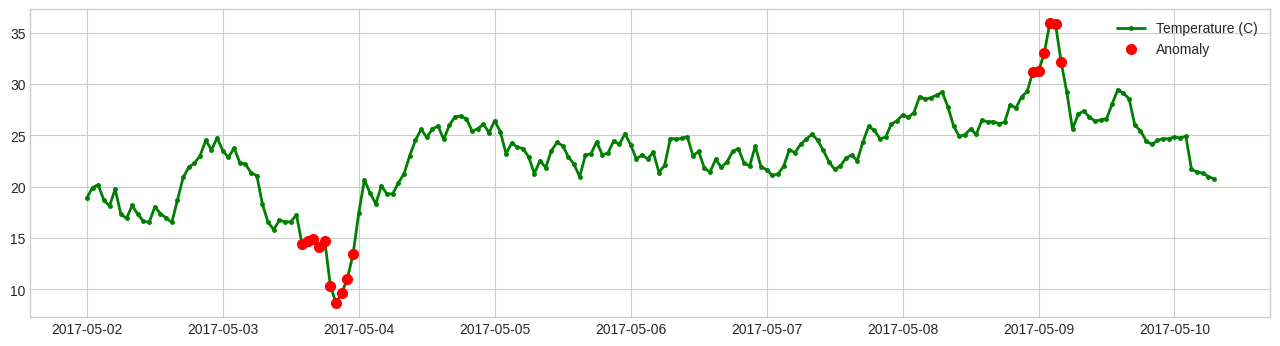

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

2. Оценка по квантилям: сравнивает каждое значение временного ряда с историческими квантилями, например:  определяем моменты времени, когда температура превышает 99%-ный процентиль или ниже 1%-ного процентиля.


**Кванти́ль**  - значение, которое заданная случайная величина не превышает с фиксированной вероятностью. Если вероятность задана в процентах, то квантиль называется **процентилем** или **перцентилем**.


*   **0,25-квантиль** называется первым (или нижним) кварти́лем;

*   **0,5-квантиль** называется медианой;

*   **0,75-квантиль** называется третьим (или верхним) кварти́лем.

In [ ]:
quantile_ad = QuantileAD(high=0.99, low=0.01)
anomalies = quantile_ad.fit_detect(s)

In [ ]:
anomalies.value_counts()

,count
Temperature (C),
False,196
True,4


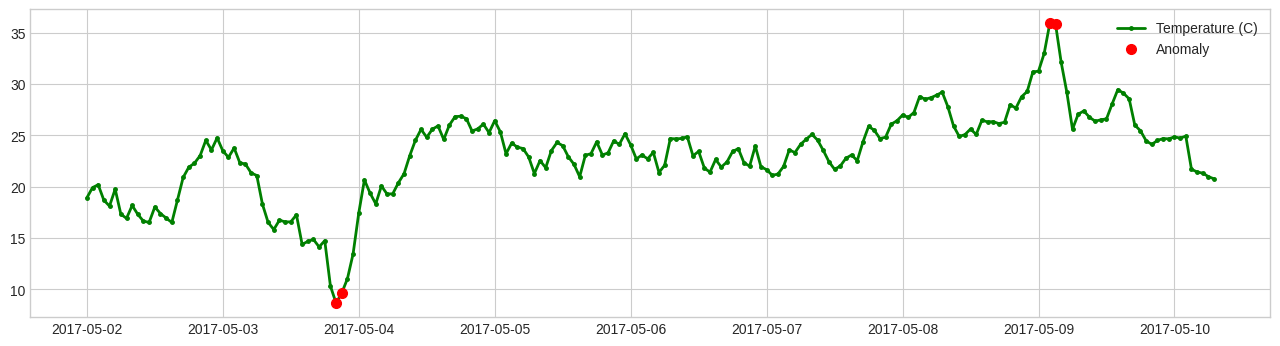

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

3. Межквартильный размах (InterQuartileRange - IQR)

## <center> Box Plot (ящик с усами)</center>

Границами ящика служат первый и третий квартили (25-й и 75-й пeрцентиль соответственно), линия в середине ящика — медиана (50-й процентиль). Концы усов — края статистически значимой выборки (без выбросов), и они могут определяться несколькими способами. Наиболее распространённые значения, определяющие длину «усов»:

*   Минимальное и максимальное наблюдаемые значения данных по выборке (в этом случае выбросы отсутствуют);
*   Разность первого квартиля и полутора межквартильных расстояний; сумма третьего квартиля и полутора межквартильных расстояний.

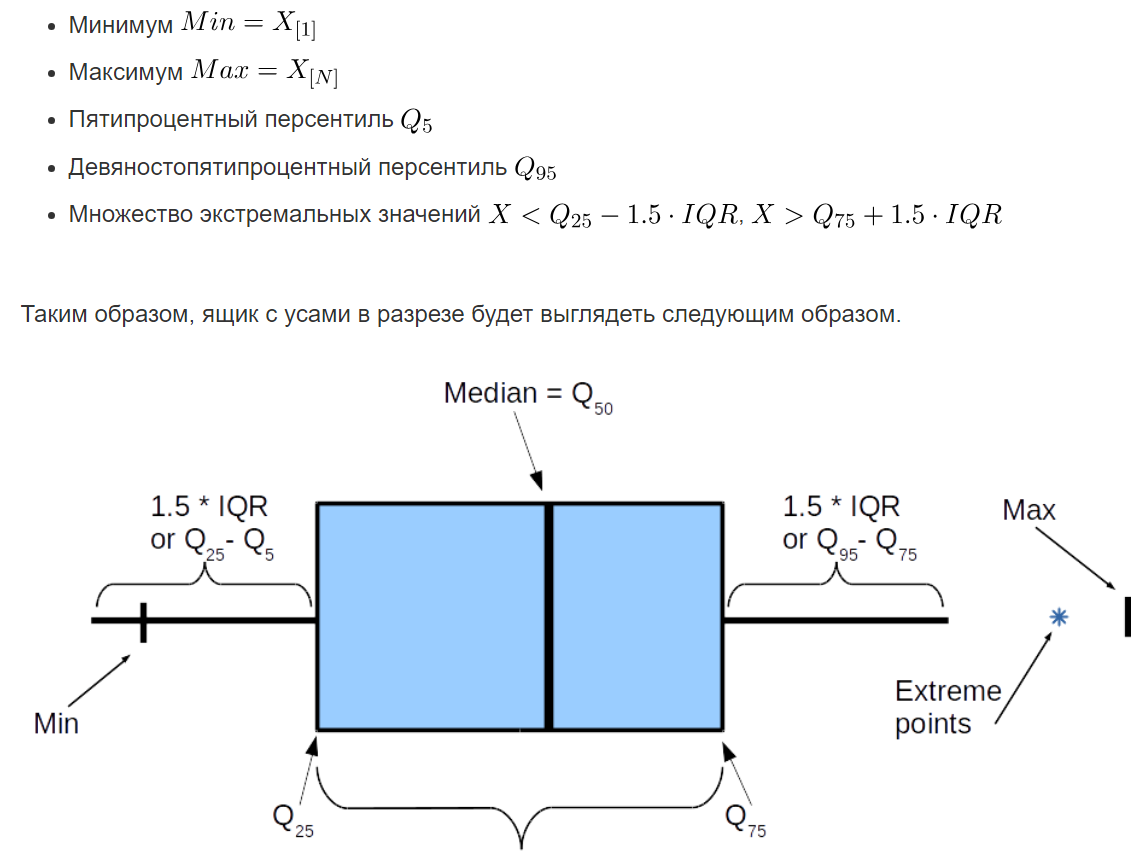

In [ ]:
iqr_ad = InterQuartileRangeAD(c=1.5) # определяем ширину размаха в IQR
anomalies = iqr_ad.fit_detect(s)

In [ ]:
anomalies.value_counts()

,count
Temperature (C),
False,187
True,13


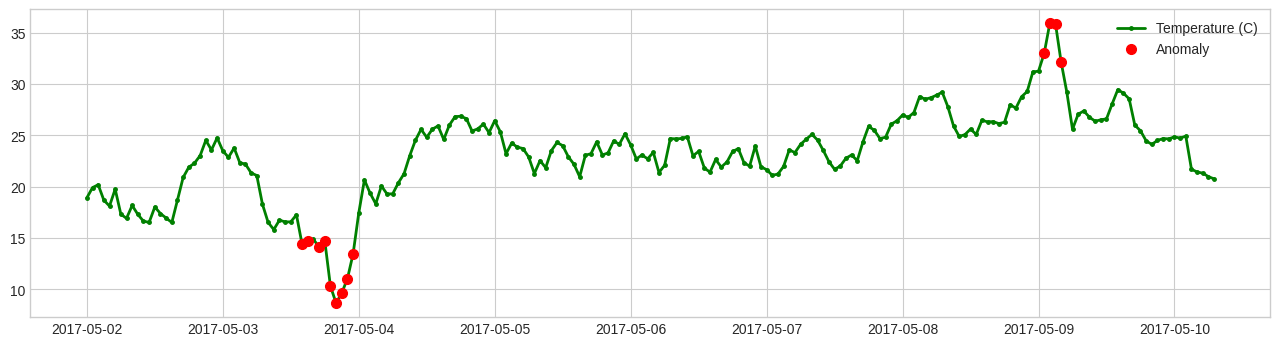

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

4. Обобщенный тест на экстремальное отклонение по Стьюденту (ESD)

ключевым допущением обобщенного теста ESD является то, что нормальные значения следуют приблизительно нормальному распределению.

In [ ]:
esd_ad = GeneralizedESDTestAD(alpha=0.3) # указывается уровень значимости
anomalies = esd_ad.fit_detect(s)

In [ ]:
anomalies.value_counts()

,count
Temperature (C),
False,194
True,6


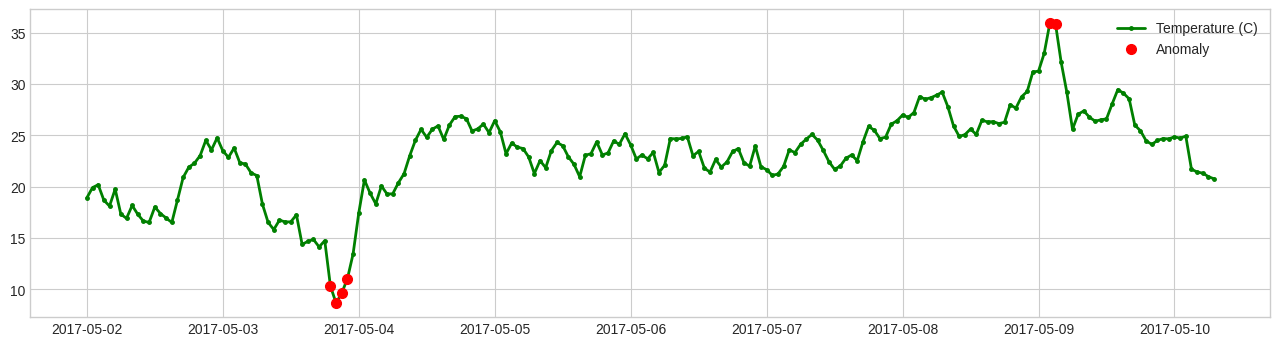

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

А как можно детектить групповые аномалии?

5.Персистентный метод (от слова Persist)
сравнивает каждое значение временного ряда с его предыдущими значениями. (онсован на процедуре двойного сглаживания с усредением DoubleRollingAggregate)

Пригоден для оценки поворотных точек и групповых аномалий

In [ ]:
from adtk.detector import PersistAD
persist_ad = PersistAD(c=1.0, side='positive')
anomalies = persist_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
Temperature (C),
False,195
True,4


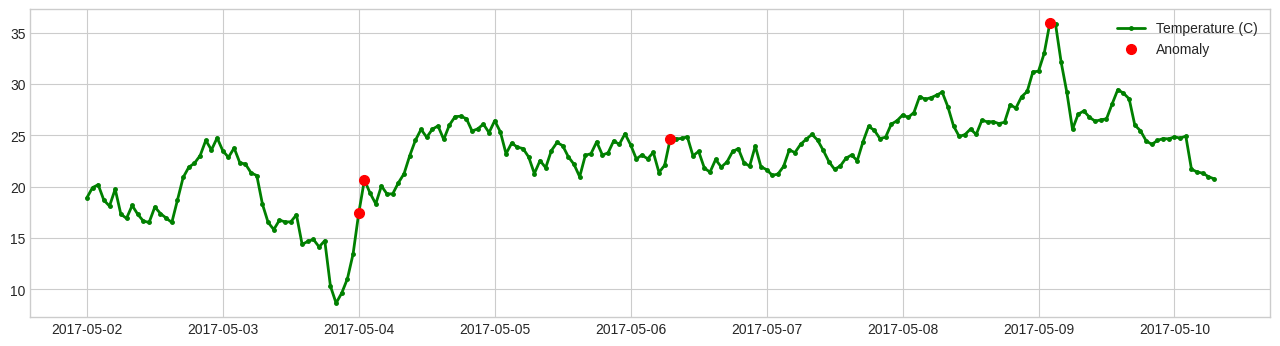

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/price_short.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

In [ ]:
persist_ad = PersistAD(c=3.0, side='positive')
anomalies = persist_ad.fit_detect(s)
# plot(s, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red');

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
Price ($),
False,198
True,1


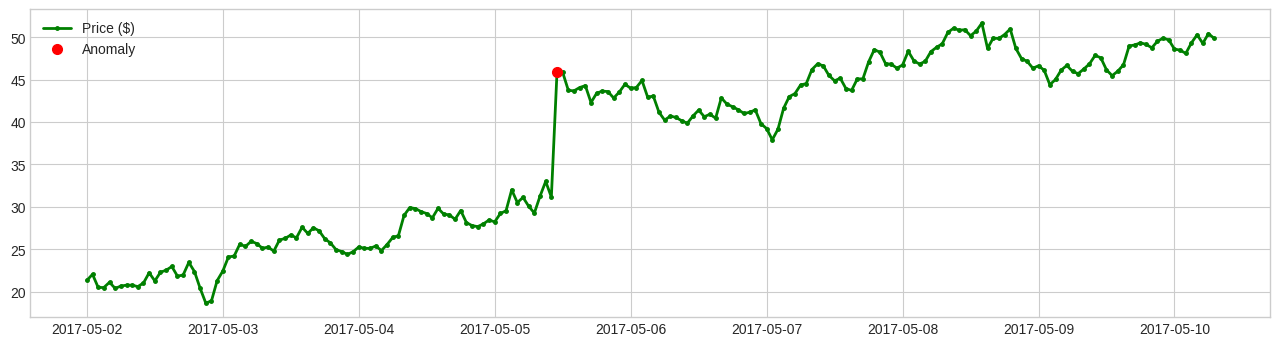

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

# anomaly_tag="span" - позволяет выделять область аномальных точек на графике, но не работает из-за обновлений (

По умолчанию PersistAD проверяется только одно предыдущее значение, которое хорошо улавливает аддитивную аномалию в краткосрочном масштабе, но не в долгосрочном. В следующем примере ему не удается зафиксировать значимое падение цены в более длительном масштабе времени.

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/price_long.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

In [ ]:
persist_ad = PersistAD(c=1.5, side='negative')
anomalies = persist_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
Price ($),
False,991
True,8


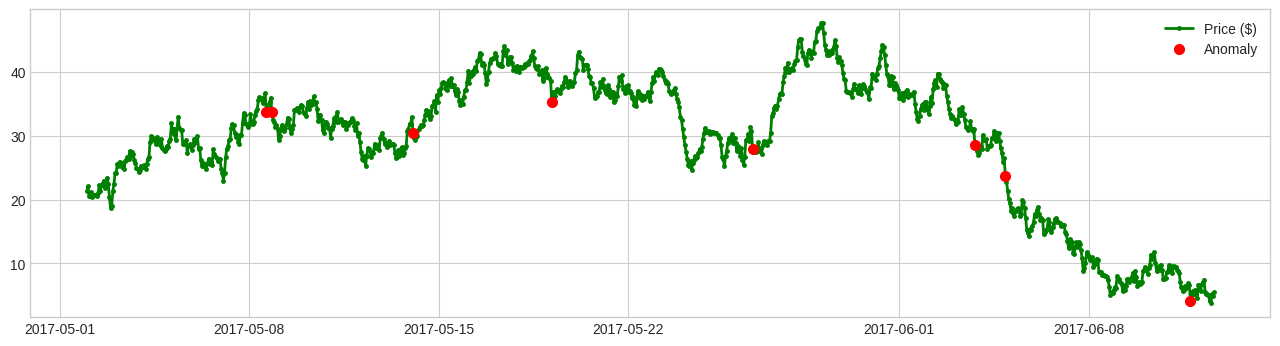

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

Мы можем изменить параметр window на число, большее 1, и детектор сравнит значение с медианой или средним значением предыдущего временного окна.

In [ ]:
persist_ad.window = 30
anomalies = persist_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
Price ($),
False,944
True,26


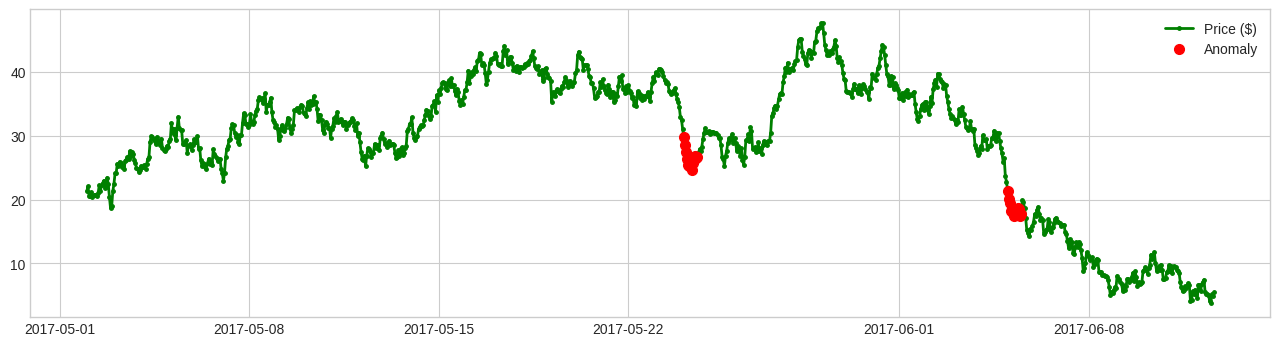

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

6. Level shift - судя по названию детектит сдвиги по уровню, при этом отслеживая разницу между средними значениями в двух скользящих временных окнах, расположенных рядом друг с другом.

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/cpu.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

In [ ]:
level_shift_ad = LevelShiftAD(c=6.0, side='both', window=5)
anomalies = level_shift_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
CPU (%),
False,981
True,10


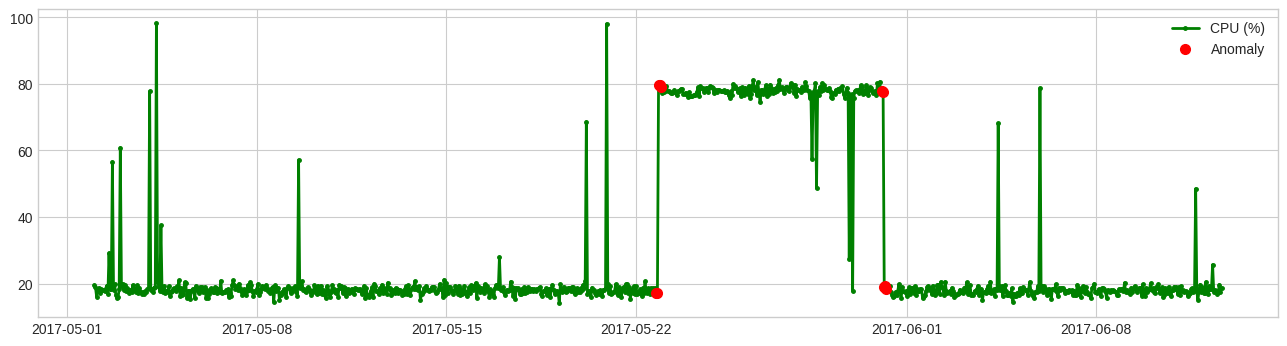

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

7. VolatilityShift - обнаруживает сдвиг уровня волатильности, отслеживая разницу между стандартными отклонениями в двух скользящих временных окнах, расположенных рядом друг с другом.

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/seismic.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

In [ ]:
volatility_shift_ad = VolatilityShiftAD(c=6.0, side='positive', window=30)
anomalies = volatility_shift_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
Seismic amplitude (mm),
False,907
True,34


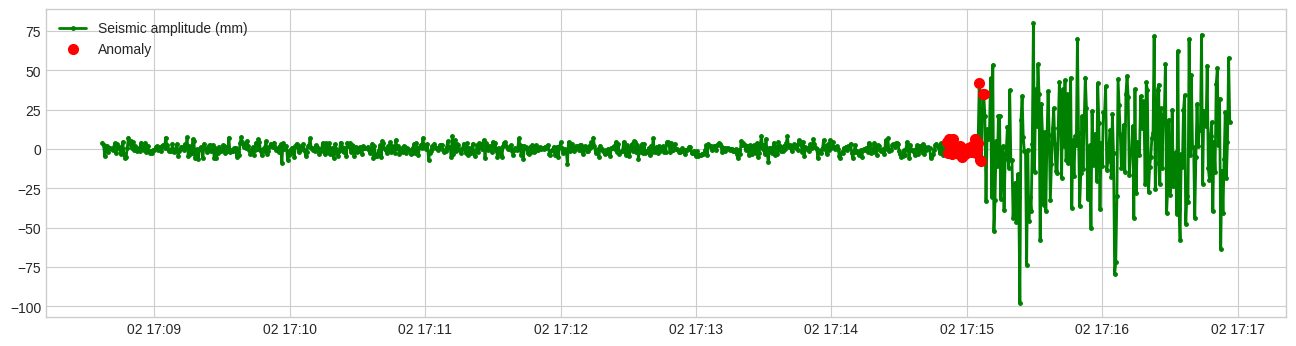

In [ ]:
plot(s, anomaly=anomalies, ts_linewidth=2, ts_markersize=5,
     anomaly_markersize=7, anomaly_color='red', anomaly_tag="marker", ts_color='g');

8. Детекция на основе сезонности - обнаруживает аномальные нарушения сезонной структуры.

алгоритм декомпозирует ряд на трендовую часть (необязательно), сезонную часть и остаточную часть. Остаточная часть может помочь выявить аномальное отклонение от сезонной модели.

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/seasonal.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

In [ ]:
seasonal_ad = SeasonalAD(c=3.0, side="both")
anomalies = seasonal_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/transformer/_transformer_1d.py:731: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9636.129032258064' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.seasonal_.iloc[i] = s.iloc[


In [ ]:
anomalies.value_counts()

,count
Traffic,
False,10048
True,272


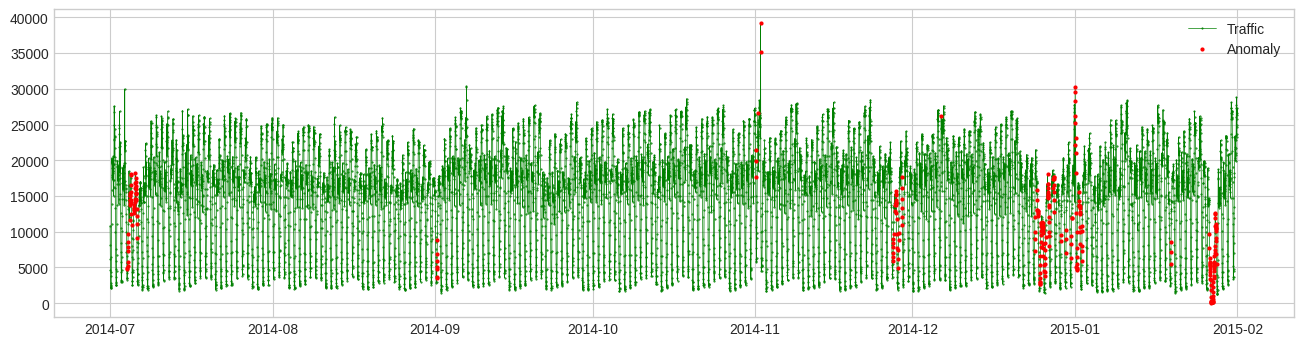

In [ ]:
plot(s, anomaly=anomalies, ts_markersize=1, anomaly_color='red', anomaly_tag="marker", anomaly_markersize=2, ts_color='g');

9. Авторегрессионные модели - обнаруживает аномальные изменения поведения авторегрессии во временных рядах: выполняет регрессию к многомерному ряду и возвращает регрессивный остаток. Это может помочь выявить аномальное нарушение обычной взаимосвязи между рядами.

In [ ]:
autoregression_ad = AutoregressionAD(n_steps=7*2, step_size=24, c=3.0)
anomalies = autoregression_ad.fit_detect(s)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


In [ ]:
anomalies.value_counts()

,count
Traffic,
False,9709
True,275


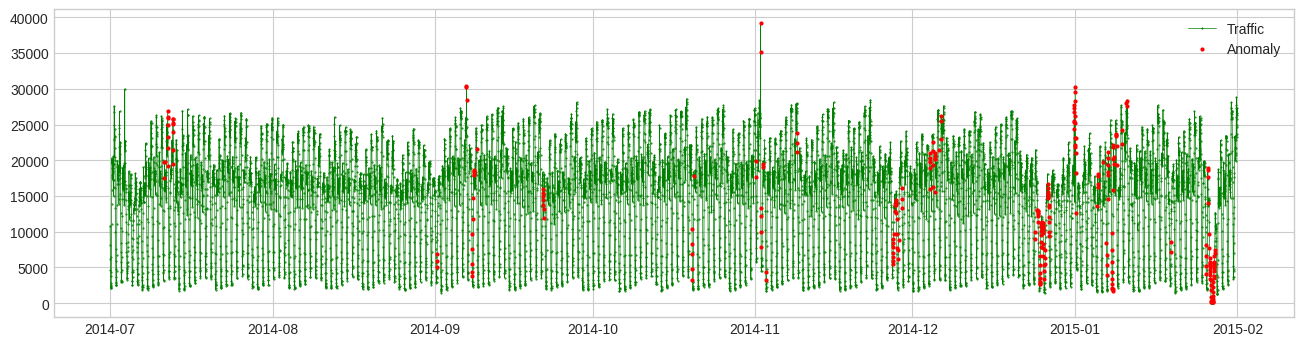

In [ ]:
plot(s, anomaly=anomalies, ts_markersize=1, anomaly_color='red', anomaly_tag="marker", anomaly_markersize=2,  ts_color='g');

10. MinClusterDetector - рассматривает многомерные временные ряды как независимые точки в многомерном пространстве, делит их на кластеры и идентифицирует значения в наименьшем кластере как аномальные.

In [ ]:
df = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/generator.csv', index_col="Time", parse_dates=True).squeeze('columns')
df = validate_series(df)

In [ ]:
min_cluster_detector = MinClusterDetector(KMeans(n_clusters=3))
anomalies = min_cluster_detector.fit_detect(df)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
anomalies.value_counts()

,count
False,380
True,20


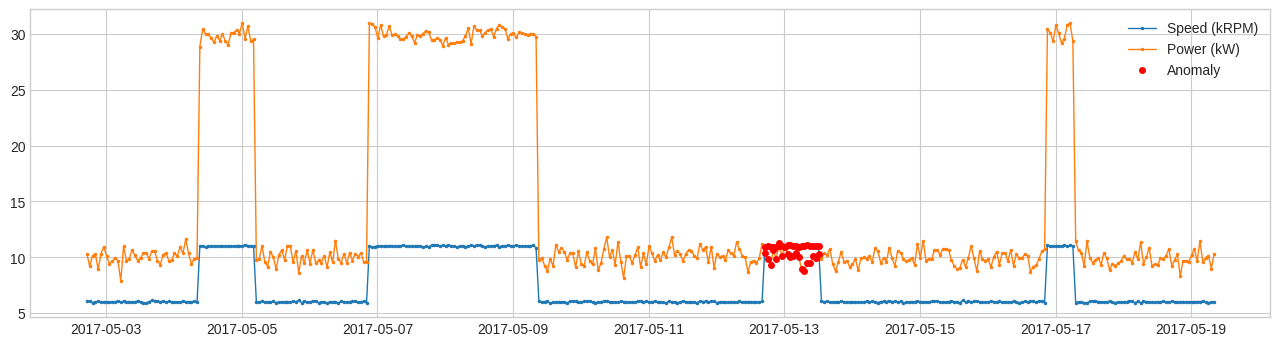

In [ ]:
plot(df, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red', anomaly_alpha=0.3, curve_group='all', anomaly_tag="marker");

11. OutlierDetector - выполняет многомерное обнаружение выбросов, не зависящее от времени, и идентифицирует выбросы как аномалии. Многомерным алгоритмом обнаружения выбросов может быть алгоритм scikit-learn или других пакетов, использующих тот же API.

Например, LocalOutlierFactor Он измеряет локальное отклонение плотности данной выборки по отношению к ее соседям. Он является локальным в том смысле, что оценка аномалии зависит от того, насколько изолирован объект относительно окружающих окрестностей.

In [ ]:
# from adtk.detector import OutlierDetector
# from sklearn.neighbors import LocalOutlierFactor

In [ ]:
outlier_detector = OutlierDetector(LocalOutlierFactor(contamination=0.05))
anomalies = outlier_detector.fit_detect(df)

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_hd.py:183: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False False False False False False False False False False
  True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 Fal

In [ ]:
anomalies.value_counts()

,count
False,380
True,20


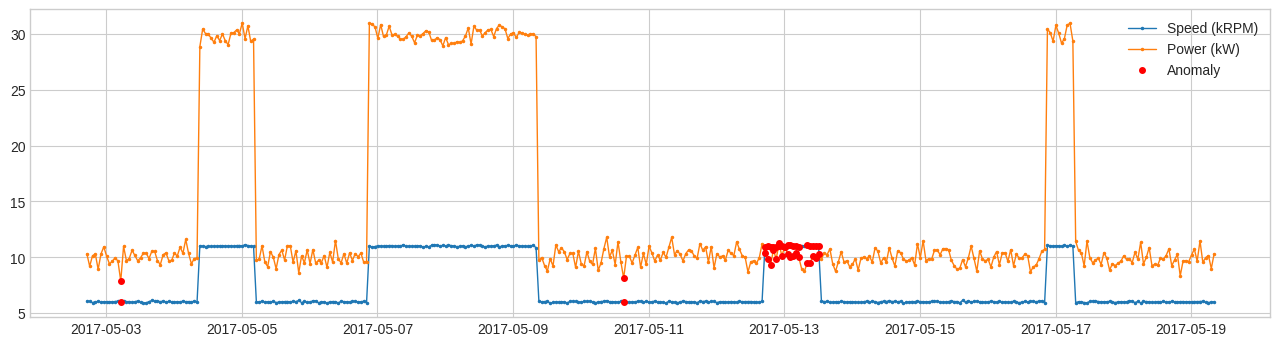

In [ ]:
plot(df, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red', anomaly_alpha=0.3, curve_group='all',anomaly_tag="marker");

12. Регрессия - обнаруживает аномальное нарушение обычной взаимосвязи между многомерными рядами путем отслеживания ошибки.

In [ ]:
# from adtk.detector import RegressionAD
# from sklearn.linear_model import LinearRegression

In [ ]:
anomalies.value_counts()

,count
False,380
True,20


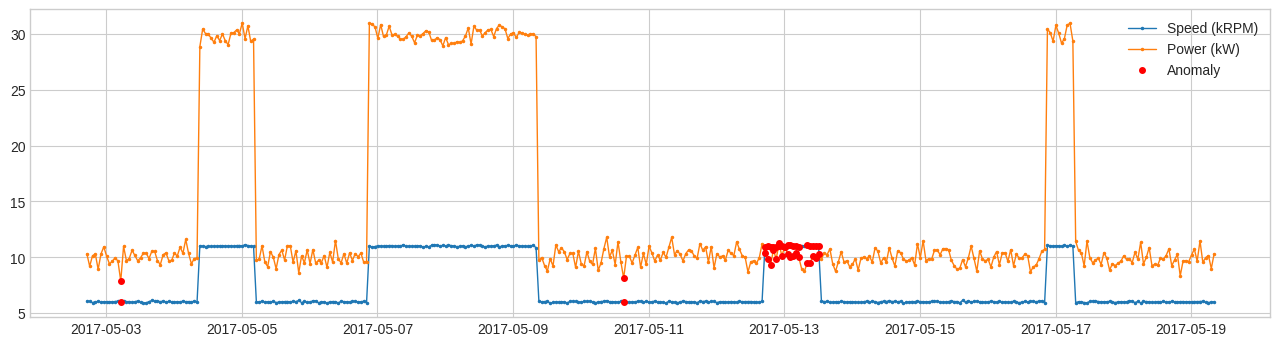

In [ ]:
plot(df, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red', anomaly_alpha=0.3, curve_group='all', anomaly_tag="marker");

13. Методы уменьшения размерности - например, PCA выполняет анализ главных компонент для многомерных временных рядов (каждая временная точка в виде вектора в многомерном пространстве) и отслеживает ошибку восстановления этих векторов.

In [ ]:
# from adtk.detector import PcaAD
pca_ad = PcaAD(k=1)
anomalies = pca_ad.fit_detect(df)


In [ ]:
anomalies.value_counts()

,count
False,380
True,20


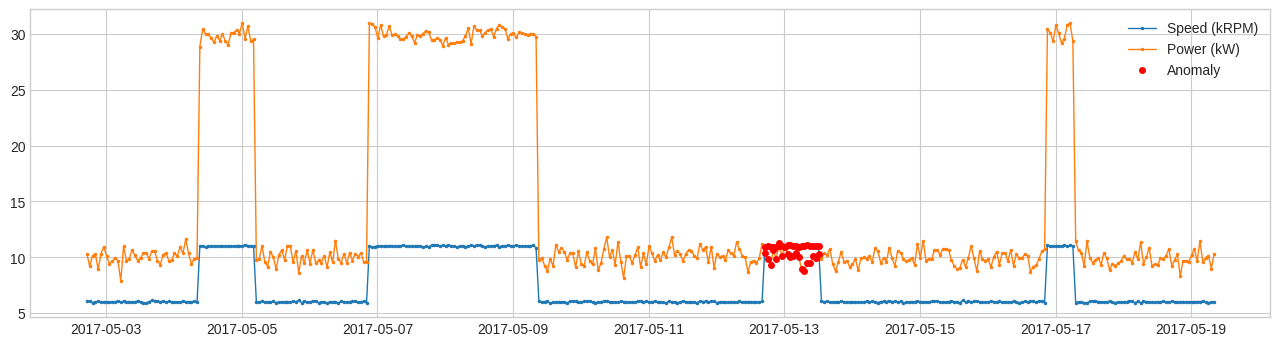

In [ ]:
plot(df, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red', anomaly_alpha=0.3, curve_group='all', anomaly_tag="marker");

14. CustomizedDetector
помогают пользователю преобразовать функцию в настраиваемый объект detector, который может использоваться (например, объектом Pipeline )

In [ ]:
df = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/generator.csv', index_col="Time", parse_dates=True)
df = validate_series(df)
df.head()

,Speed (kRPM),Power (kW)
Time,,
2017-05-02 17:08:37,6.066579,10.308257
2017-05-02 18:08:37,6.035764,9.186763
2017-05-02 19:08:37,5.922730,10.128382
2017-05-02 20:08:37,5.999581,10.290300
2017-05-02 21:08:37,6.031067,8.910037


In [ ]:
# Пишем собственную функцию для определения возаимосвязи нормального поведения системы в зависимости от факторов
def myDetectionFunc(df):
    return (df["Speed (kRPM)"] * 1.2 > df["Power (kW)"])

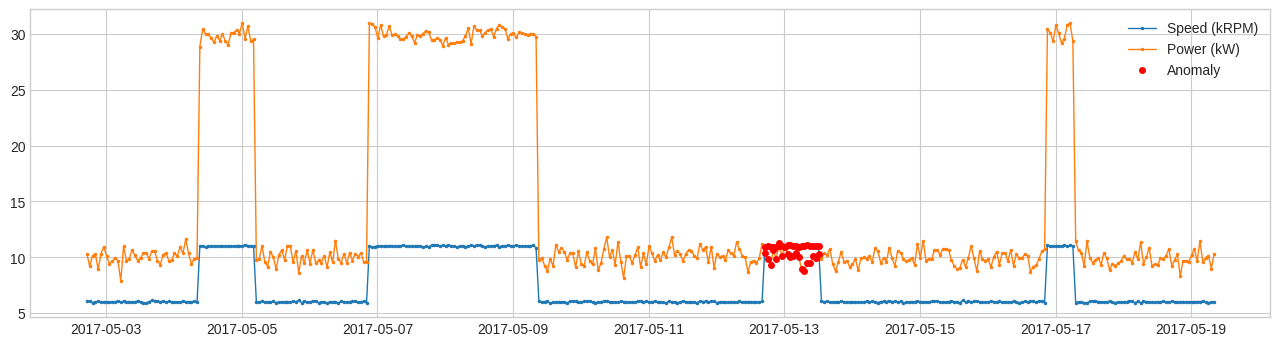

In [ ]:
# from adtk.detector import CustomizedDetectorHD
customized_detector = CustomizedDetectorHD(detect_func=myDetectionFunc)
anomalies = customized_detector.detect(df)
plot(df, anomaly=anomalies, ts_linewidth=1, ts_markersize=3, anomaly_color='red', anomaly_alpha=0.3, curve_group='all', anomaly_tag="marker");

## А что под капотом????

1. Скользящее среднее - RollingAggregate


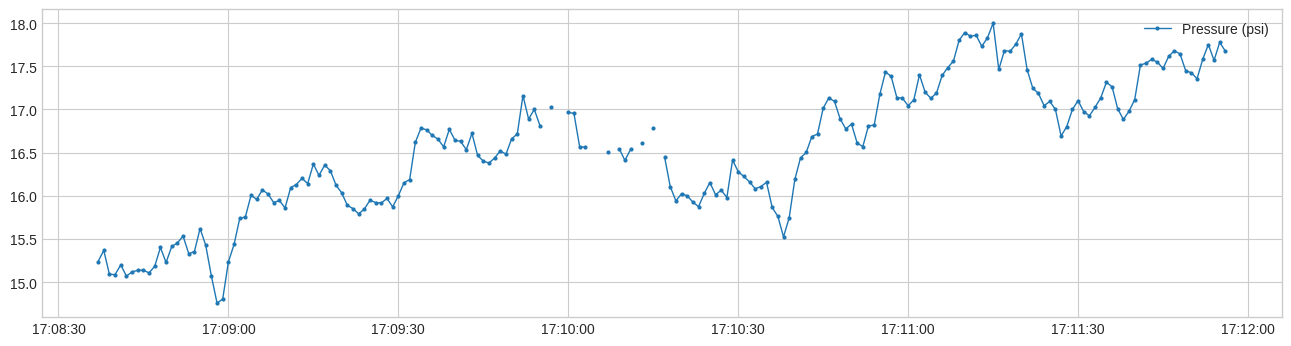

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/pressure.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)
plot(s, ts_linewidth=1, ts_markersize=4);

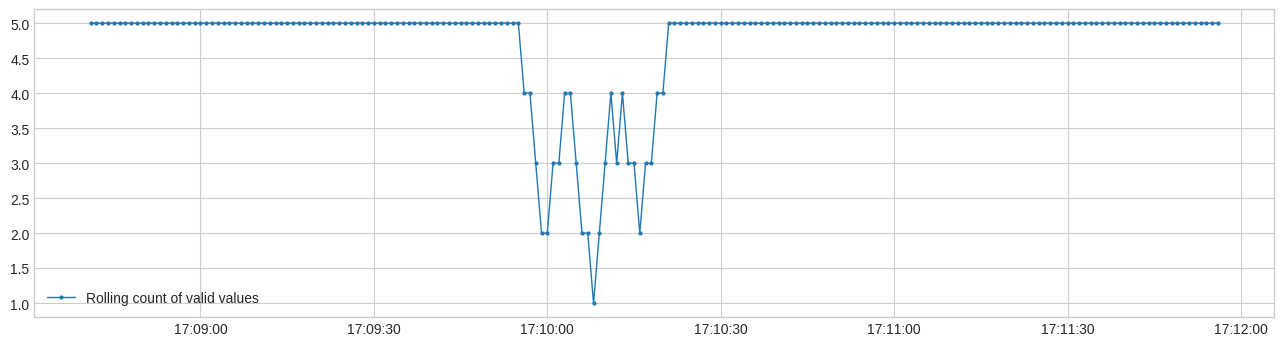

In [ ]:
from adtk.transformer import RollingAggregate
s_transformed = RollingAggregate(agg='count', window=5).transform(s)
plot(s_transformed.rename("Rolling count of valid values"), ts_linewidth=1, ts_markersize=4);

2. Двойное скользящее среднее - DoubleRollingAggregate

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/seismic.csv', index_col="Time", parse_dates=True).squeeze('columns')
s=validate_series(s)

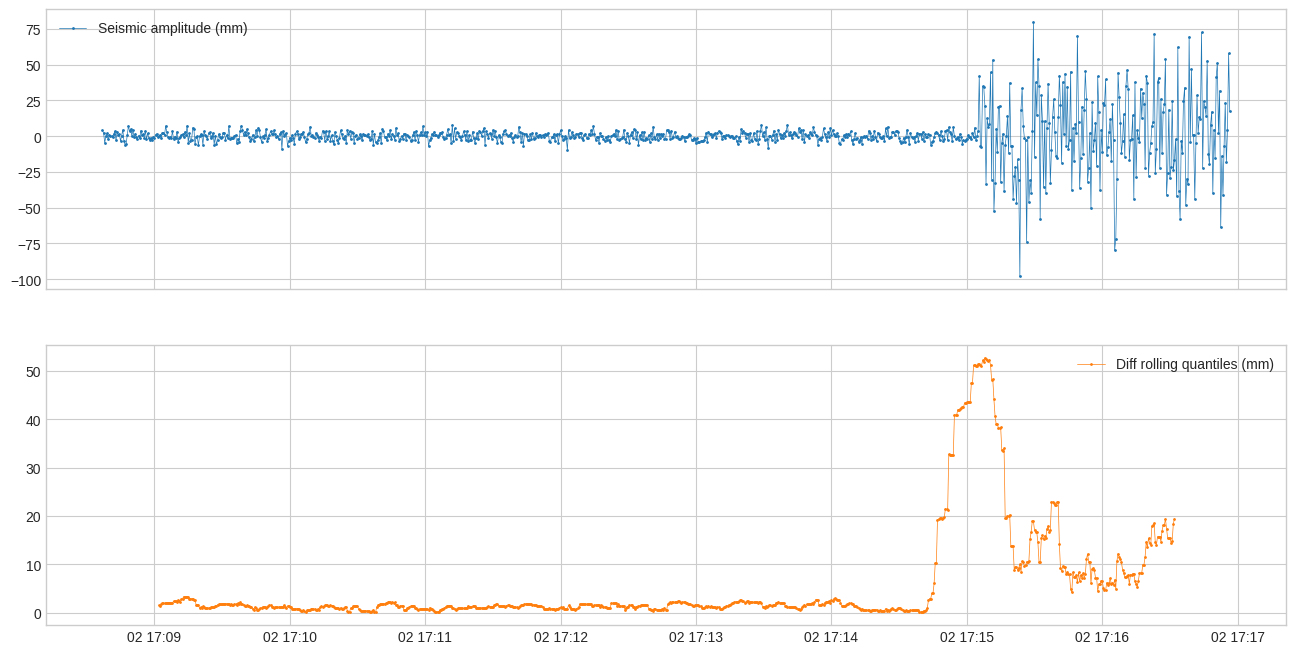

In [ ]:
from adtk.transformer import DoubleRollingAggregate
s_transformed = DoubleRollingAggregate(
    agg="quantile",
    agg_params={"q": [0.1, 0.5, 0.9]},
    window=50,
    diff="l2").transform(s).rename("Diff rolling quantiles (mm)")

plot(pd.concat([s, s_transformed], axis=1));

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/cpu.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

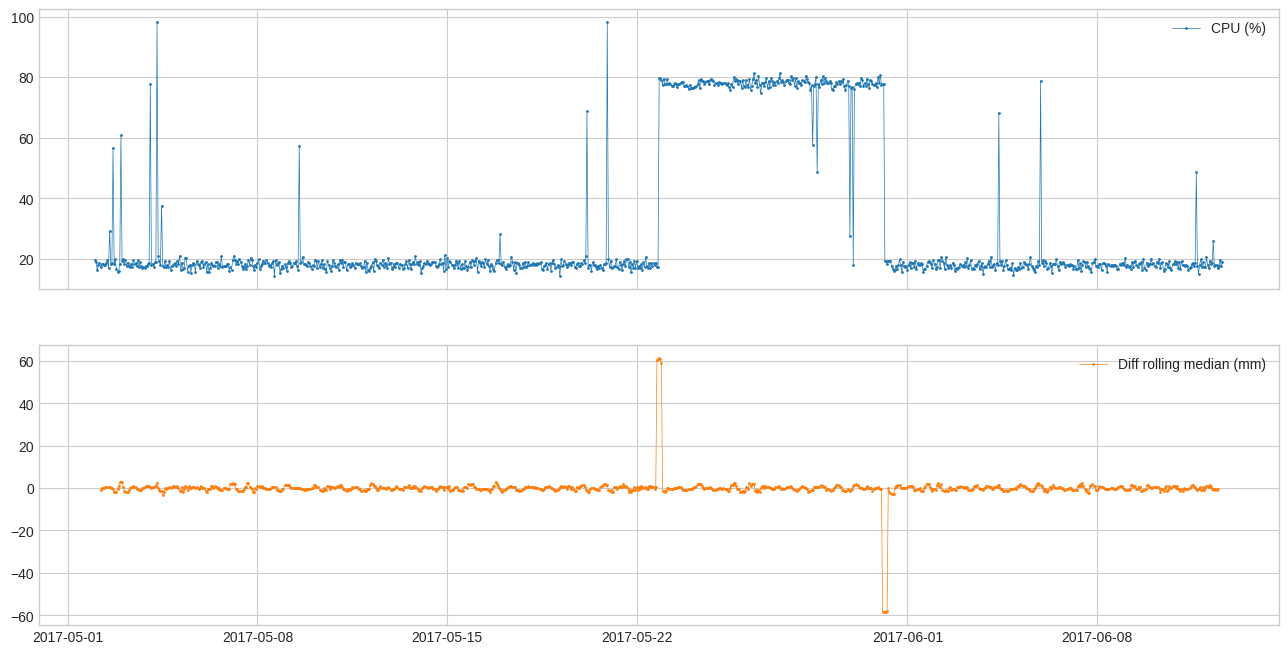

In [ ]:
from adtk.transformer import DoubleRollingAggregate
s_transformed = DoubleRollingAggregate(
    agg="median",
    window=5,
    diff="diff").transform(s).rename("Diff rolling median (mm)")

plot(pd.concat([s, s_transformed], axis=1));

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/price_short.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

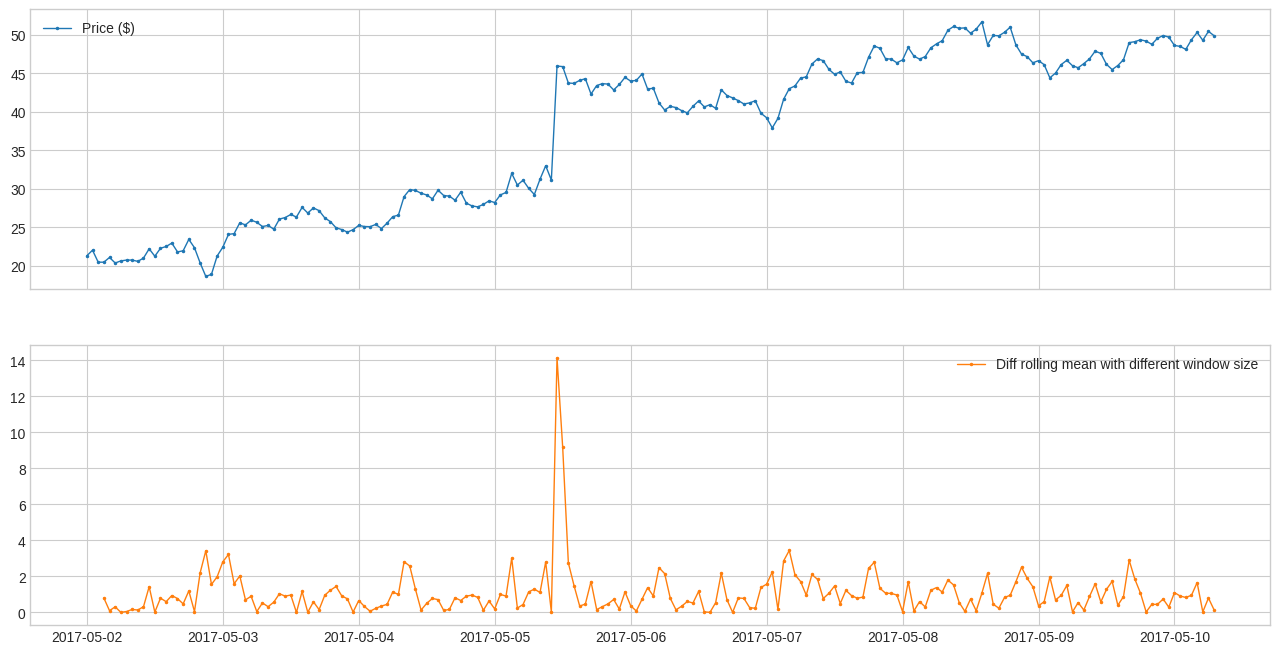

In [ ]:
from adtk.transformer import DoubleRollingAggregate
s_transformed = DoubleRollingAggregate(
    agg="mean",
    window=(3,1), #The tuple specifies the left window to be 3, and right window to be 1
    diff="l1").transform(s).rename("Diff rolling mean with different window size")

plot(pd.concat([s, s_transformed], axis=1), ts_linewidth=1, ts_markersize=3);

3. ClassicSeasonalDecomposition

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/seasonal.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

/usr/local/lib/python3.10/dist-packages/adtk/transformer/_transformer_1d.py:731: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9636.129032258064' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.seasonal_.iloc[i] = s.iloc[


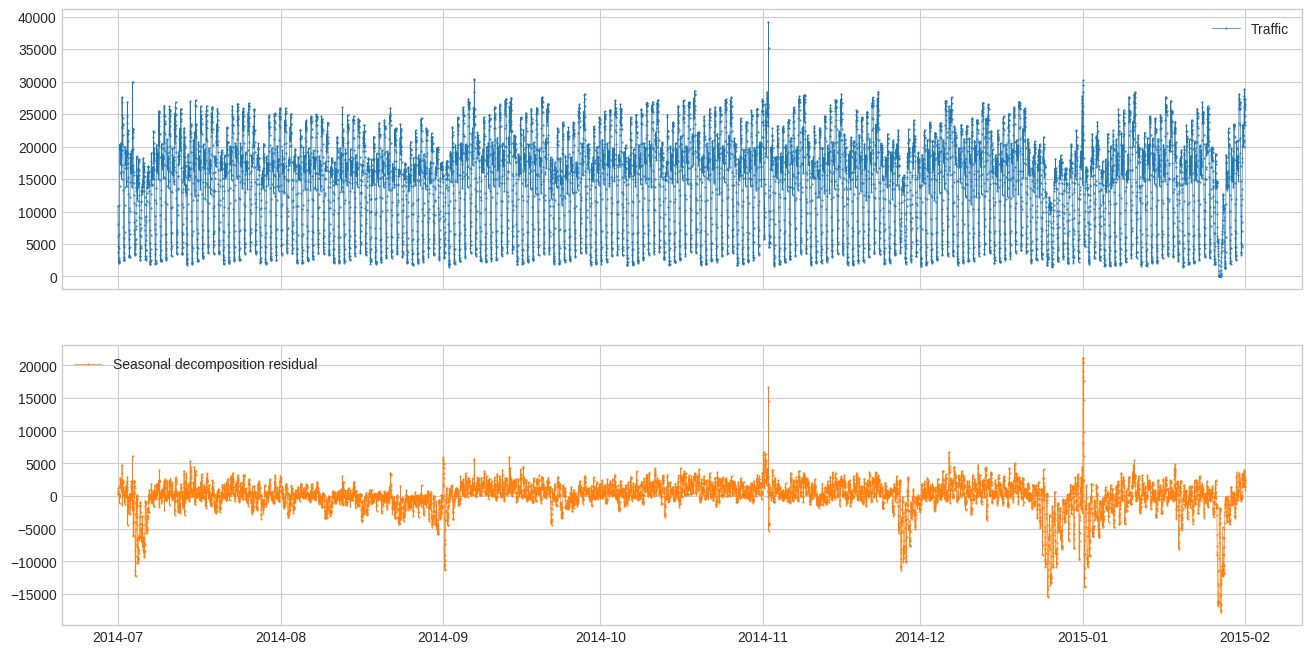

In [ ]:
from adtk.transformer import ClassicSeasonalDecomposition
s_transformed = ClassicSeasonalDecomposition().fit_transform(s).rename("Seasonal decomposition residual")
plot(pd.concat([s, s_transformed], axis=1), ts_markersize=1);

без извлечения тренда невозможно обрабатывать случаи, когда долгосрочный тренд смешивается с сезонной компонентой, а также с шумом. В таких случаях следует включить опцию trend

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/seasonal+trend.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)

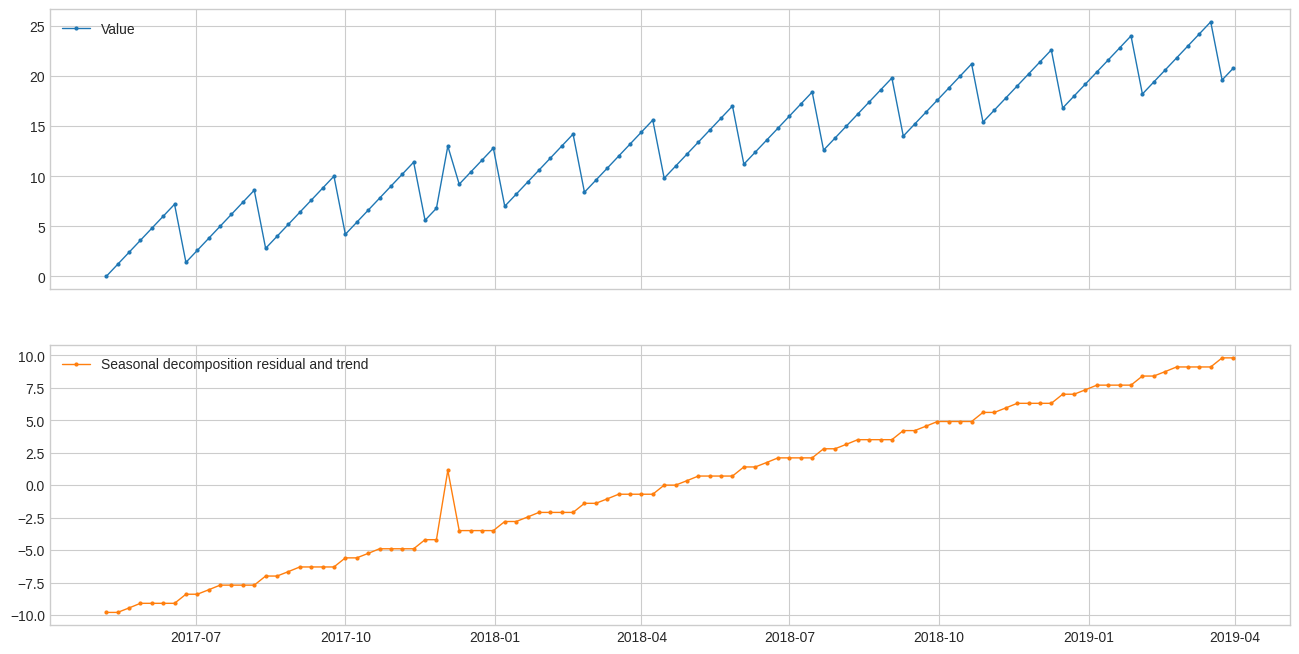

In [ ]:
s_transformed = ClassicSeasonalDecomposition(freq=7).fit_transform(s).rename("Seasonal decomposition residual and trend")
plot(pd.concat([s, s_transformed], axis=1), ts_linewidth=1, ts_markersize=4);

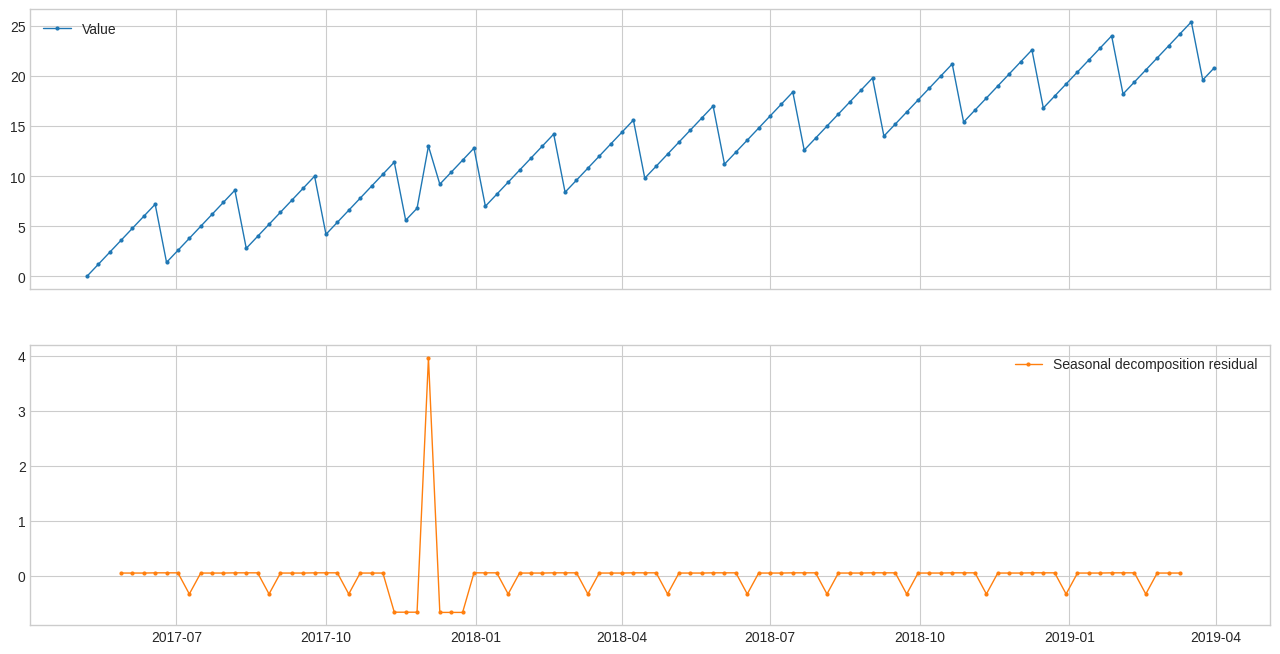

In [ ]:

s_transformed = ClassicSeasonalDecomposition(freq=7, trend=True).fit_transform(s).rename("Seasonal decomposition residual")
plot(pd.concat([s, s_transformed], axis=1), ts_linewidth=1, ts_markersize=4);

4. Pipeline

Комплексирование методов выделения аномалий

In [ ]:
from adtk.pipe import Pipeline
steps = [
    ("deseasonal", ClassicSeasonalDecomposition()),
    ("quantile_ad", QuantileAD(high=0.995, low=0.005))
]
pipeline = Pipeline(steps)

/usr/local/lib/python3.10/dist-packages/adtk/transformer/_transformer_1d.py:731: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9636.129032258064' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.seasonal_.iloc[i] = s.iloc[


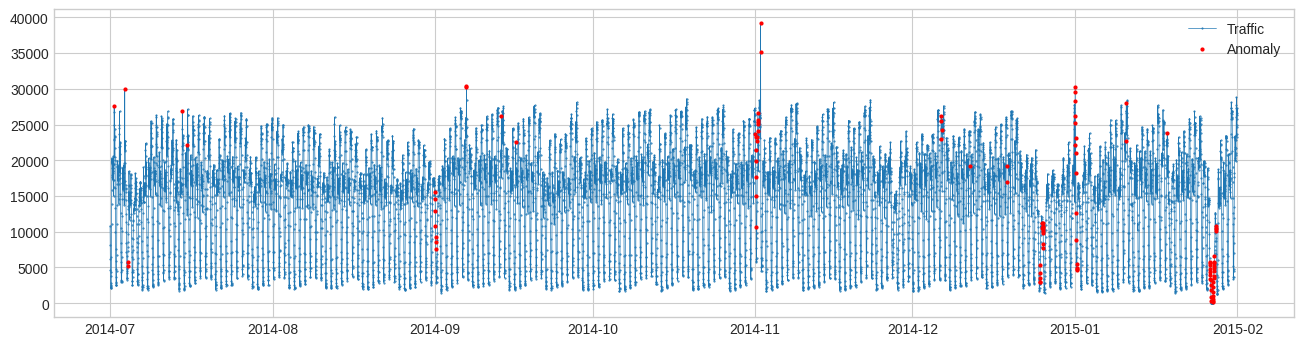

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/seasonal.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)
anomalies = pipeline.fit_detect(s)
plot(s, anomaly=anomalies, ts_markersize=1, anomaly_markersize=2, anomaly_tag="marker", anomaly_color='red');

/usr/local/lib/python3.10/dist-packages/adtk/transformer/_transformer_1d.py:731: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9636.129032258064' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.seasonal_.iloc[i] = s.iloc[


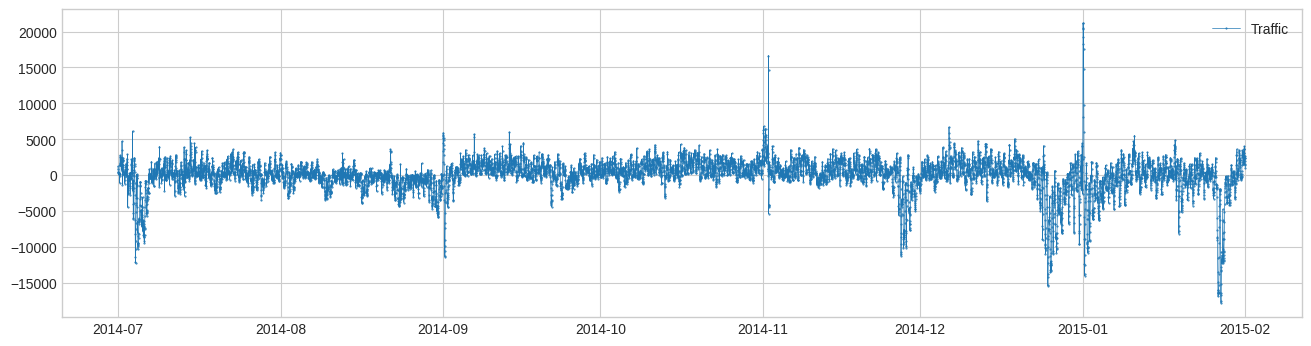

In [ ]:
results = pipeline.fit_detect(s, return_intermediate=True)
plot(results["deseasonal"], ts_markersize=1);

5. Pipenet - для НЕпоследовательной комбинации

In [ ]:
from adtk.pipe import Pipenet
from adtk.aggregator import AndAggregator
steps = {
    "abs_level_change": {
        "model": DoubleRollingAggregate(
            agg="median",
            window=10,
            center=True,
            diff="l1"
        ),
        "input": "original"
    },
    "level_shift": {
        "model": InterQuartileRangeAD(c=3.0),
        "input": "abs_level_change"
    },
    "level_change": {
        "model": DoubleRollingAggregate(
            agg="median",
            window=10,
            center=True,
            diff="diff"
        ),
        "input": "original",
    },
    "positive_level_change": {
        "model": ThresholdAD(high=0),
        "input": "level_change"
    },
    "positive_level_shift": {
        "model": AndAggregator(),
        "input": ["level_shift", "positive_level_change"]
    }
}
pipenet = Pipenet(steps)

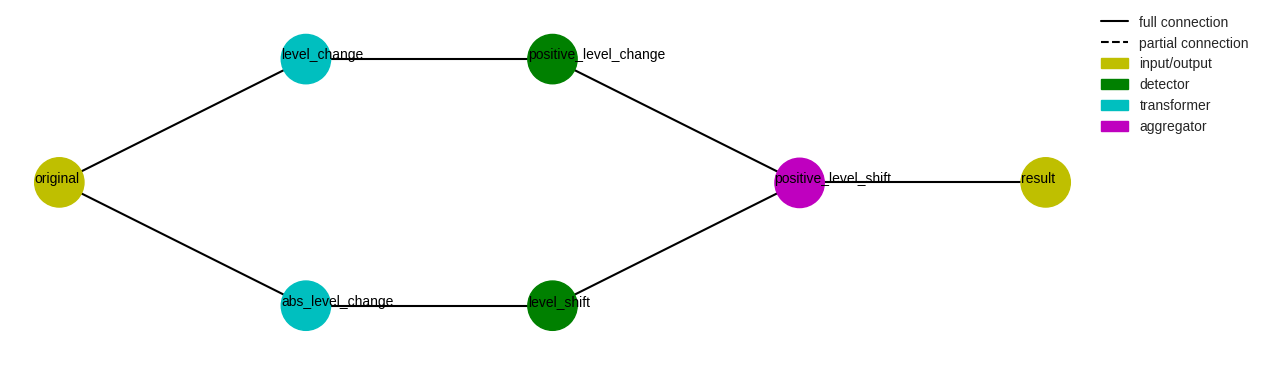

In [ ]:
pipenet.plot_flowchart();

In [ ]:
pipenet.get_params()


{'abs_level_change': {'window': 10,
  'agg': 'median',
  'agg_params': None,
  'center': True,
  'min_periods': None},
 'level_shift': {'c': 3.0},
 'level_change': {'window': 10,
  'agg': 'median',
  'agg_params': None,
  'center': True,
  'min_periods': None},
 'positive_level_change': {'low': None, 'high': 0},
 'positive_level_shift': {}}

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


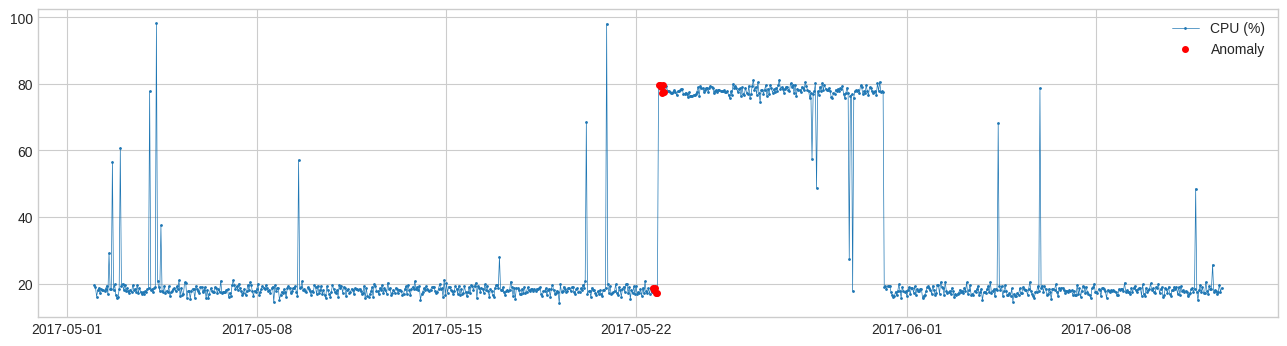

In [ ]:
s = pd.read_csv('https://github.com/arundo/adtk/raw/develop/docs/notebooks/data/cpu.csv', index_col="Time", parse_dates=True).squeeze('columns')
s = validate_series(s)
anomalies = pipenet.fit_detect(s)
plot(s, anomaly=anomalies, anomaly_color='red', anomaly_tag="marker");

пользователь имеет возможность получать промежуточные ряды и списки аномалий

/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:270: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/detector/_detector_1d.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[s.isna()] = np.nan
/usr/local/lib/python3.10/dist-packages/adtk/aggregator/_aggregator.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  predicted[predicted & lists.isna().any(axis=1)] = float("nan")


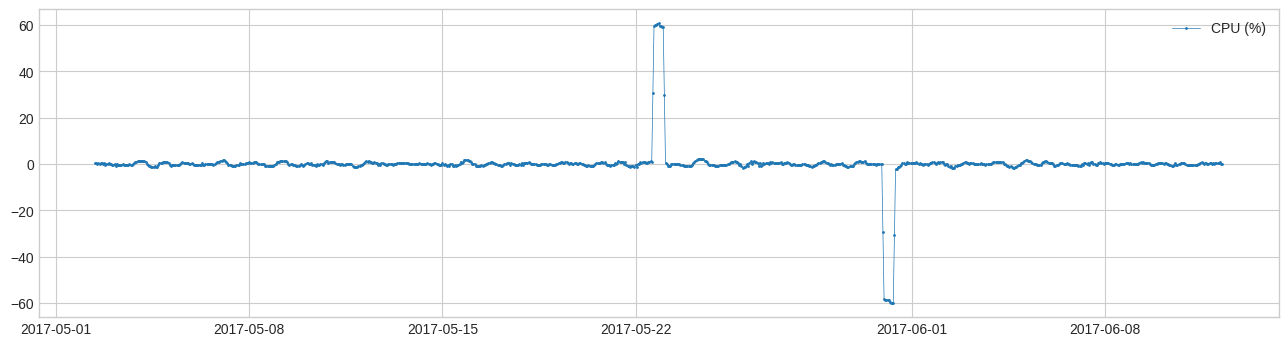

In [ ]:
results = pipenet.fit_detect(s, return_intermediate=True)
plot(results["level_change"]);

CUSUM Anomaly Detection (CAD)

In [ ]:
pip install pyanom

In [ ]:
from pyanom.outlier_detection import CAD

In [ ]:
y_normal = np.loadtxt(
   "https://raw.githubusercontent.com/ground0state/pyanom/master/demo/data/timeseries_normal.csv", delimiter=",").reshape(-1, 1)
y_error = np.loadtxt(
   "https://raw.githubusercontent.com/ground0state/pyanom/master/demo/data/timeseries_error.csv", delimiter=",").reshape(-1, 1)


print(y_normal.shape)
print(y_error.shape)


(100, 1)
(100, 1)


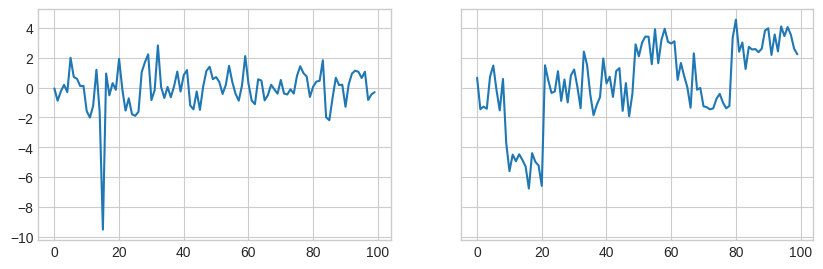

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

ax[0].plot(y_normal)
ax[1].plot(y_error)
plt.show()

In [ ]:
model = CAD(threshold=1.0) #
model.fit(y_normal)

CAD(threshold=1.0)

In [ ]:
anomaly_score = model.score(y_error)

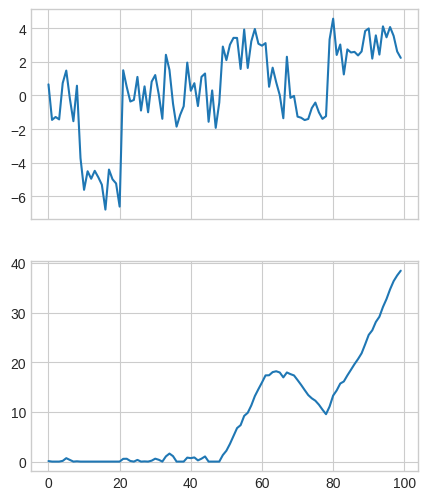

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
ax[0].plot(y_error)
ax[1].plot(anomaly_score)
plt.show()